# Get data


Get the degree (completions) data from the c_a table

In [1]:
import duckdb

con = duckdb.connect("ipeds.duckdb", read_only=True)

query = """
SELECT 
    h.unitid,
    h.year,
    h.institution_name,
    h.city,
    h.state,
    h.carnegie,                  
    cp.* EXCLUDE (unitid, year)    
FROM hd h
LEFT JOIN (
    PIVOT c_a                                      
    ON cipcode
    USING SUM(ctotalt) AS degrees       
    GROUP BY unitid, year
) cp
    ON h.unitid = cp.unitid 
   AND h.year   = cp.year
"""

df = con.sql(query).df()

print(df.shape)
df.head()

(162442, 1971)


,unitid,year,institution_name,city,state,carnegie,1.0_degrees,1.0101_degrees,1.0102_degrees,1.0103_degrees,...,9.0905_degrees,9.0906_degrees,9.0907_degrees,9.0908_degrees,9.0909_degrees,9.0999_degrees,9.1001_degrees,9.9999_degrees,95.95_degrees,99.0_degrees
0,117751,2022,The Master's University and Seminary,Santa Clarita,CA,32.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,444.0
1,131283,2022,The Catholic University of America,Washington,DC,15.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1522.0
2,136400,2022,Pasco-Hernando State College,New Port Richey,FL,40.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.0
3,141264,2022,Valdosta State University,Valdosta,GA,21.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2592.0
4,142522,2022,Brigham Young University-Idaho,Rexburg,ID,40.0,NaN,22.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8121.0


Select most recent year

In [15]:
dfl = df[ df.year == 2023 ].reset_index(drop=True)
dfl

,unitid,year,institution_name,city,state,carnegie,1.0_degrees,1.0101_degrees,1.0102_degrees,1.0103_degrees,...,9.0905_degrees,9.0906_degrees,9.0907_degrees,9.0908_degrees,9.0909_degrees,9.0999_degrees,9.1001_degrees,9.9999_degrees,95.95_degrees,99.0_degrees
0,142443,2023,North Idaho College,Coeur d'Alene,ID,40.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1523.0
1,153472,2023,Indian Hills Community College,Ottumwa,IA,40.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,738.0
2,172264,2023,Siena Heights University,Adrian,MI,21.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,629.0
3,172699,2023,Western Michigan University,Kalamazoo,MI,15.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,50.0,NaN,NaN,NaN,4743.0
4,173735,2023,Minnesota North College,Hibbing,MN,40.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,982.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,440916,2023,Southern University Law Center,Baton Rouge,LA,-2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6159,443368,2023,Illinois Eastern Community College-System Office,Olney,IL,-2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6160,459189,2023,Cosmo Beauty Academy,Sacramento,CA,-2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6161,486460,2023,Wright Graduate University for the Realization...,Elkhorn,WI,-2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# PCA

dfv are just the value (numeric) columns

In [16]:
unitid = dfl['unitid']
dfv = dfl.drop(columns=['unitid', 'year', 'institution_name', 'city', 'state', 'carnegie']).fillna(0)
dfv

,1.0_degrees,1.0101_degrees,1.0102_degrees,1.0103_degrees,1.0104_degrees,1.0105_degrees,1.0106_degrees,1.0199_degrees,1.0201_degrees,1.0204_degrees,...,9.0905_degrees,9.0906_degrees,9.0907_degrees,9.0908_degrees,9.0909_degrees,9.0999_degrees,9.1001_degrees,9.9999_degrees,95.95_degrees,99.0_degrees
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1523.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,738.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,629.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0,0.0,4743.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,982.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
dfs = pd.DataFrame(scaler.fit_transform(dfv),
                         columns=dfv.columns,
                         index=dfv.index)
dfs

,1.0_degrees,1.0101_degrees,1.0102_degrees,1.0103_degrees,1.0104_degrees,1.0105_degrees,1.0106_degrees,1.0199_degrees,1.0201_degrees,1.0204_degrees,...,9.0905_degrees,9.0906_degrees,9.0907_degrees,9.0908_degrees,9.0909_degrees,9.0999_degrees,9.1001_degrees,9.9999_degrees,95.95_degrees,99.0_degrees
0,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,-0.042364,-0.041708,-0.05523,0.0,0.299349
1,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,-0.042364,-0.041708,-0.05523,0.0,-0.063747
2,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,-0.042364,-0.041708,1.04456,0.0,-0.114164
3,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,8.838281,-0.041708,-0.05523,0.0,1.788735
4,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,-0.042364,-0.041708,-0.05523,0.0,0.049114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,-0.042364,-0.041708,-0.05523,0.0,-0.405103
6159,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,-0.042364,-0.041708,-0.05523,0.0,-0.405103
6160,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,-0.042364,-0.041708,-0.05523,0.0,-0.405103
6161,-0.101232,-0.085408,-0.092517,-0.043652,-0.048179,-0.0252,-0.025263,-0.027524,-0.051795,-0.027055,...,-0.067061,-0.058643,-0.034245,-0.046955,-0.034857,-0.042364,-0.041708,-0.05523,0.0,-0.405103


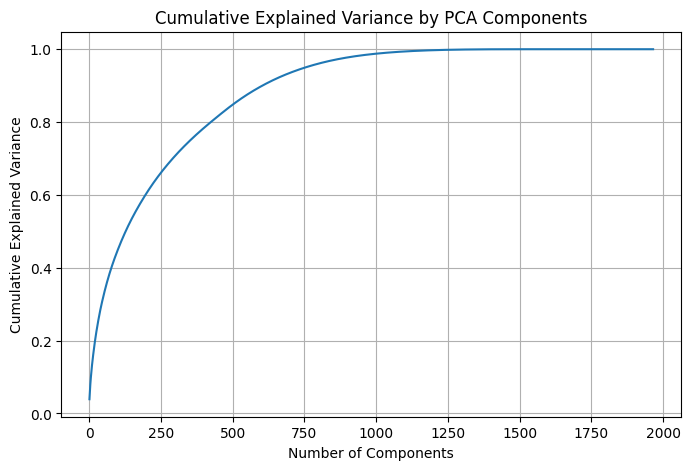

In [18]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


# Perform PCA
pca = PCA()
np_pca = pca.fit_transform(dfs)
df_pca = pd.DataFrame(np_pca)
df_pca['unitid'] = unitid

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Component loadings
loadings = pca.components_.T  # shape: (n_features, n_components)


# NN

In [19]:
df_pca[df_pca['unitid'] == 195474].head()

,0,1,2,3,4,5,6,7,8,9,...,1956,1957,1958,1959,1960,1961,1962,1963,1964,unitid
419,0.911639,-0.355748,0.778715,0.864363,0.148223,-0.906081,1.092016,-0.410627,-0.224574,-0.842024,...,5.065125e-17,1.004510e-17,-7.025021e-17,1.115833e-17,7.192418e-18,4.391414e-17,1.654268e-17,-1.369698e-16,-3.280436e-16,195474


In [20]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd

# ================================================================
# 1. Choose how many top PCA components you want to use for NN
# ================================================================
n_top_components = 100          # ← change this number anytime (e.g. 50, 200, etc.)

# ================================================================
# 2. Prepare the feature matrix using ONLY the top N PCA components
# ================================================================
# df_pca columns look like: [0, 1, 2, ..., 'unitid']
pca_feature_cols = list(range(n_top_components))          # columns 0, 1, 2, ..., 99

X_pca = df_pca[pca_feature_cols].values                   # shape: (n_institutions, 100)

print(f"Using top {n_top_components} PCA components for Nearest Neighbors")
print(f"Feature matrix shape: {X_pca.shape}")

# ================================================================
# 3. Fit NearestNeighbors on the reduced PCA space
# ================================================================
nn = NearestNeighbors(
    n_neighbors=11,           # 10 closest + itself
    metric='euclidean',       # you can also try 'cosine' here
    algorithm='auto'
)
nn.fit(X_pca)

# ================================================================
# 4. Find the target institution
# ================================================================
target_unitid = 195474                     # ← your target (updated from your latest code)
target_mask = df_pca['unitid'] == target_unitid   # make sure column name matches your df_pca

if not target_mask.any():
    raise ValueError(f"unitid {target_unitid} not found in the dataset!")

target_idx = df_pca[target_mask].index[0]
target_vector = X_pca[target_idx].reshape(1, -1)

# ================================================================
# 5. Get the nearest neighbors
# ================================================================
distances, indices = nn.kneighbors(target_vector)

# ================================================================
# 6. Build clean results DataFrame
# ================================================================
results = pd.DataFrame({
    'rank': range(len(indices[0])),
    'unitid': df_pca.iloc[indices[0]]['unitid'].values,
    'distance': distances[0],
    'is_target': df_pca.iloc[indices[0]]['unitid'].values == target_unitid
})

print("Nearest neighbors to unitid", target_unitid, "using top", n_top_components, "PCA components:")
print(results.round(4))

# Optional: top 5 excluding itself
print("\nTop 5 most similar institutions (excluding itself):")
print(results[results['is_target'] == False].head(5)[['rank', 'unitid', 'distance']].round(4))

Using top 100 PCA components for Nearest Neighbors
Feature matrix shape: (6163, 100)
Nearest neighbors to unitid 195474 using top 100 PCA components:
    rank  unitid  distance  is_target
0      0  195474    0.0000       True
1      1  492962    4.9199      False
2      2  114123    5.1104      False
3      3  239716    5.2268      False
4      4  123448    5.3121      False
5      5  152530    5.3791      False
6      6  145372    5.4568      False
7      7  220215    5.4637      False
8      8  119173    5.4756      False
9      9  168263    5.4760      False
10    10  229780    5.5287      False

Top 5 most similar institutions (excluding itself):
   rank  unitid  distance
1     1  492962    4.9199
2     2  114123    5.1104
3     3  239716    5.2268
4     4  123448    5.3121
5     5  152530    5.3791


In [ ]:
top5_unitids = results.loc[~results['is_target'], 'unitid'].head(5).tolist()

top5_info = (
    dfl.set_index('unitid')
       .loc[top5_unitids, ['institution_name', 'city', 'state', 'carnegie']]
       .reset_index()
)

top5_info